In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sklearn
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

import seaborn as sns
import matplotlib.pyplot as plt

def correlation_matrix(df):
    plt.figure(figsize=(15, 12))
    sns.heatmap(
        df.corr(),
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm",
        vmin=-1, vmax=1,
        square=True
    )
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()



def train_test_split(x, y, test_size=0.2, random_state=32):
    n = len(x)
    np.random.seed(random_state)
    indices = np.arange(n)
    np.random.shuffle(indices)
    split_point = int(n * (1 - test_size))
    train_idx = indices[:split_point]
    test_idx = indices[split_point:]
    x_train = x.iloc[train_idx]
    x_test = x.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    return x_train, x_test, y_train, y_test


def linear_regression(x_train, y_train, x_test, y_test):
    model = LinearRegression()
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    train_mse = mean_squared_error(y_train, model.predict(x_train))
    train_r2 = r2_score(y_train, model.predict(x_train))
    test_mse = mean_squared_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)
    return model, train_mse, test_mse, train_r2, test_r2

def ridge_regression(x_train, y_train, x_test, y_test, alpha=1.0):
    model = Ridge(alpha=alpha)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    train_mse = mean_squared_error(y_train, model.predict(x_train))
    train_r2 = r2_score(y_train, model.predict(x_train))
    test_mse = mean_squared_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)
    return model, train_mse, test_mse, train_r2, test_r2

def lasso_regression(x_train, y_train, x_test, y_test, alpha=1.0):
    model = Lasso(alpha=alpha)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    train_mse = mean_squared_error(y_train, model.predict(x_train))
    train_r2 = r2_score(y_train, model.predict(x_train))
    test_mse = mean_squared_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)
    return model, train_mse, test_mse, train_r2, test_r2

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

def ols_results(x,y,test_size=0.2,random_state=32):
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size,random_state)
    model,train_mse,test_mse,train_r2,test_r2=linear_regression(x_train,y_train,x_test,y_test)
    feature_names=list(x.columns)
    row={"Train MSE":train_mse,"Test MSE":test_mse,"Train R2":train_r2,"Test R2":test_r2}
    for name,coef in zip(feature_names,model.coef_):
        row[name]=coef
    return pd.DataFrame([row]).round(4)

def ridge_results(x,y,test_size=0.2,random_state=32,alpha_list=[0.001,0.003,0.01,0.03,0.1,0.3,1,3,10,30,100]):
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size,random_state)
    feature_names=list(x.columns)
    results=[]
    for alpha in alpha_list:
        model,train_mse,test_mse,train_r2,test_r2=ridge_regression(x_train,y_train,x_test,y_test,alpha)
        row={"Alpha":alpha,"Train MSE":train_mse,"Test MSE":test_mse,"Train R2":train_r2,"Test R2":test_r2}
        for name,coef in zip(feature_names,model.coef_):
            row[name]=coef
        results.append(row)
    return pd.DataFrame(results).round(4)

def lasso_results(x,y,test_size=0.2,random_state=32,alpha_list=[0.001,0.003,0.01,0.03,0.1,0.3,1,3,10,30,100]):
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size,random_state)
    feature_names=list(x.columns)
    results=[]
    for alpha in alpha_list:
        model,train_mse,test_mse,train_r2,test_r2=lasso_regression(x_train,y_train,x_test,y_test,alpha)
        row={"Alpha":alpha,"Train MSE":train_mse,"Test MSE":test_mse,"Train R2":train_r2,"Test R2":test_r2}
        for name,coef in zip(feature_names,model.coef_):
            row[name]=coef
        results.append(row)
    return pd.DataFrame(results).round(4)

# Dataset 1 - Housing Features

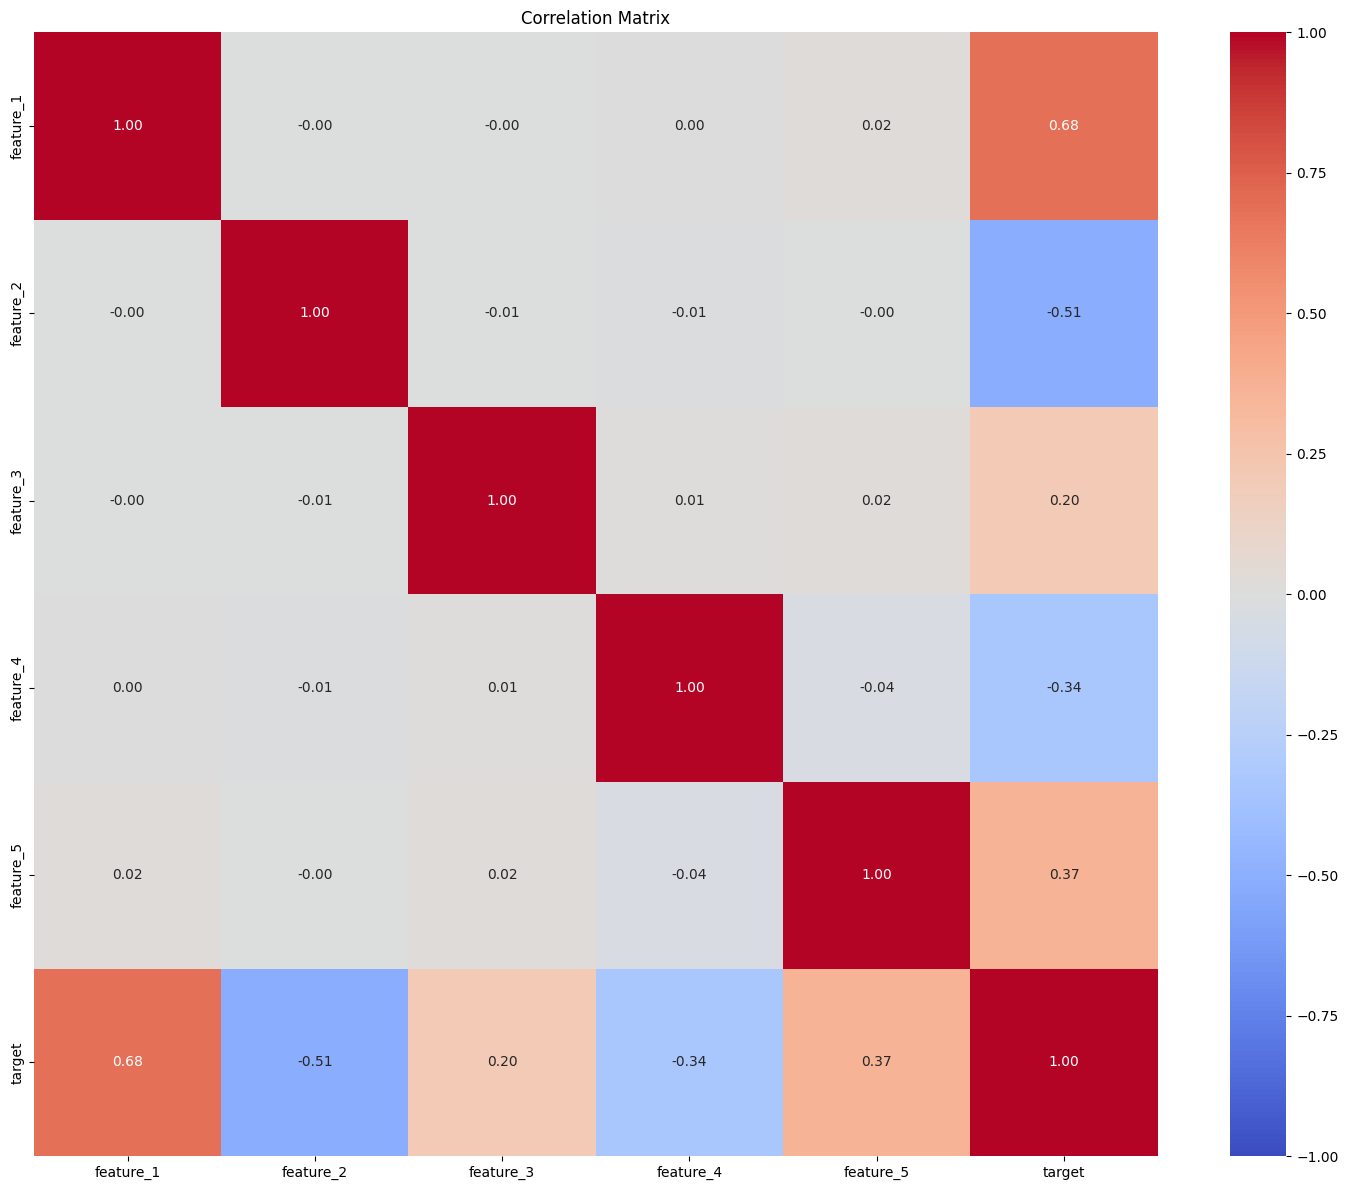

Ordinary Least Squares Regression Results:

   Train MSE  Test MSE  Train R2  Test R2  feature_1  feature_2  feature_3  feature_4  feature_5
0     0.9961    0.9952    0.9989   0.9989    19.9883   -14.9671      1.994    -9.9623     9.9997




Ridge Regression Results:

      Alpha  Train MSE  Test MSE  Train R2  Test R2  feature_1  feature_2  feature_3  feature_4  feature_5
0     0.001     0.9961    0.9952    0.9989   0.9989    19.9883   -14.9671     1.9940    -9.9623     9.9997
1     0.003     0.9961    0.9952    0.9989   0.9989    19.9883   -14.9671     1.9940    -9.9623     9.9997
2     0.010     0.9961    0.9952    0.9989   0.9989    19.9883   -14.9670     1.9940    -9.9623     9.9997
3     0.030     0.9961    0.9952    0.9989   0.9989    19.9882   -14.9670     1.9940    -9.9622     9.9996
4     0.100     0.9961    0.9952    0.9989   0.9989    19.9878   -14.9667     1.9940    -9.9621     9.9995
5     0.300     0.9961    0.9951    0.9989   0.9989    19.9868   -14.9660     1.9939    -

In [3]:
house_data = pd.read_csv('housing_features.csv')
house_x = house_data.drop(columns=['target'])
house_y = house_data['target']
correlation_matrix(house_data)
print("Ordinary Least Squares Regression Results:\n")
print(ols_results(house_x, house_y))
print("\n\n\n")
print("Ridge Regression Results:\n")
print(ridge_results(house_x, house_y))
print("\n\n\n")
print("Lasso Regression Results:\n")
print(lasso_results(house_x, house_y))

Number of samples (n): 5000
Number of features (p): 5
Training R^2: 0.9989


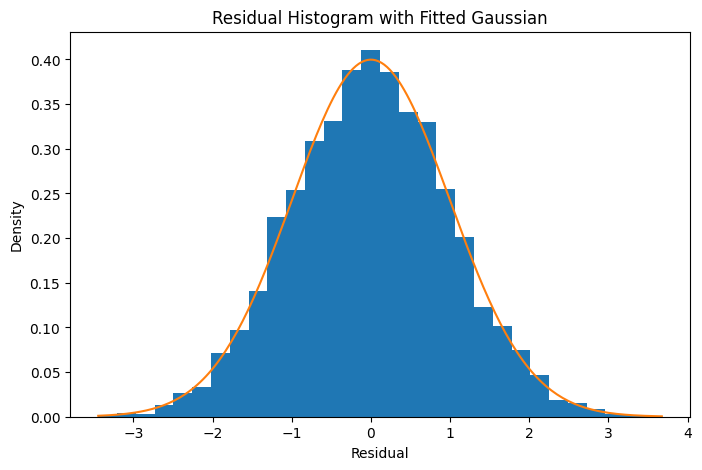

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

n = len(house_x)
p = house_x.shape[1]

print(f"Number of samples (n): {n}")
print(f"Number of features (p): {p}")

model = LinearRegression()
model.fit(house_x, house_y)

y_hat = model.predict(house_x)
residuals = house_y - y_hat

r2 = r2_score(house_y, y_hat)
print(f"Training R^2: {r2:.4f}")

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, density=True)

mu = np.mean(residuals)
sigma = np.std(residuals)

x_vals = np.linspace(min(residuals), max(residuals), 200)
plt.plot(x_vals, stats.norm.pdf(x_vals, mu, sigma))

plt.title("Residual Histogram with Fitted Gaussian")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.show()


#### Q1

n >> p here (large dataset, only 5 features), so OLS is already near-optimal. The residuals are roughly Gaussian, which is exactly when OLS is the best unbiased linear estimator, adding regularization makes it worse.

#### Q2

Lasso shrinks all coefficients toward zero approximately at the same rate. Features with smaller OLS coefficients hit zero first. The strongest predictor survives longest because it has the most signal to "spend" before being zeroed.

In [5]:
x_train,x_test,y_train,y_test=train_test_split(house_x,house_y)

np.random.seed(42)

noise=1.2*np.std(y_train)*np.random.randn(len(y_train))
y_train_noisy=y_train+noise

N_small=100
indices=np.random.choice(len(x_train),N_small,replace=False)
x_small=x_train.iloc[indices]
y_small=y_train_noisy.iloc[indices]

print("Gaussian Noise + Small Sample Size:\n")

print("Ordinary Least Squares:\n")
print(ols_results(x_small,y_small))

print("\nRidge Regression (moderate penalties):\n")
print(ridge_results(x_small,y_small,alpha_list=[1,5,10,20]))



Gaussian Noise + Small Sample Size:

Ordinary Least Squares:

   Train MSE   Test MSE  Train R2  Test R2  feature_1  feature_2  feature_3  feature_4  feature_5
0  1292.1864  1842.4667    0.5214   0.2992     26.757   -21.4269     2.2467    -1.4411    14.8085

Ridge Regression (moderate penalties):

   Alpha  Train MSE   Test MSE  Train R2  Test R2  feature_1  feature_2  feature_3  feature_4  feature_5
0      1  1292.4207  1836.5014    0.5213   0.3015    26.4672   -21.0512     2.2337    -1.5034    14.5871
1      5  1297.4175  1819.3990    0.5195   0.3080    25.3734   -19.6687     2.1857    -1.7155    13.7664
2     10  1310.5298  1809.6512    0.5146   0.3117    24.1363   -18.1714     2.1331    -1.9132    12.8655
3     20  1350.0931  1813.9381    0.5000   0.3101    22.0116   -15.7589     2.0459    -2.1558    11.3844


#### Q3

With added noise and only N=30 samples, OLS overfits badly, test MSE increases. Ridge stays more stable because it doesn't try to fit every noisy sample perfectly. If the dataset is smaller, more regularization works better.

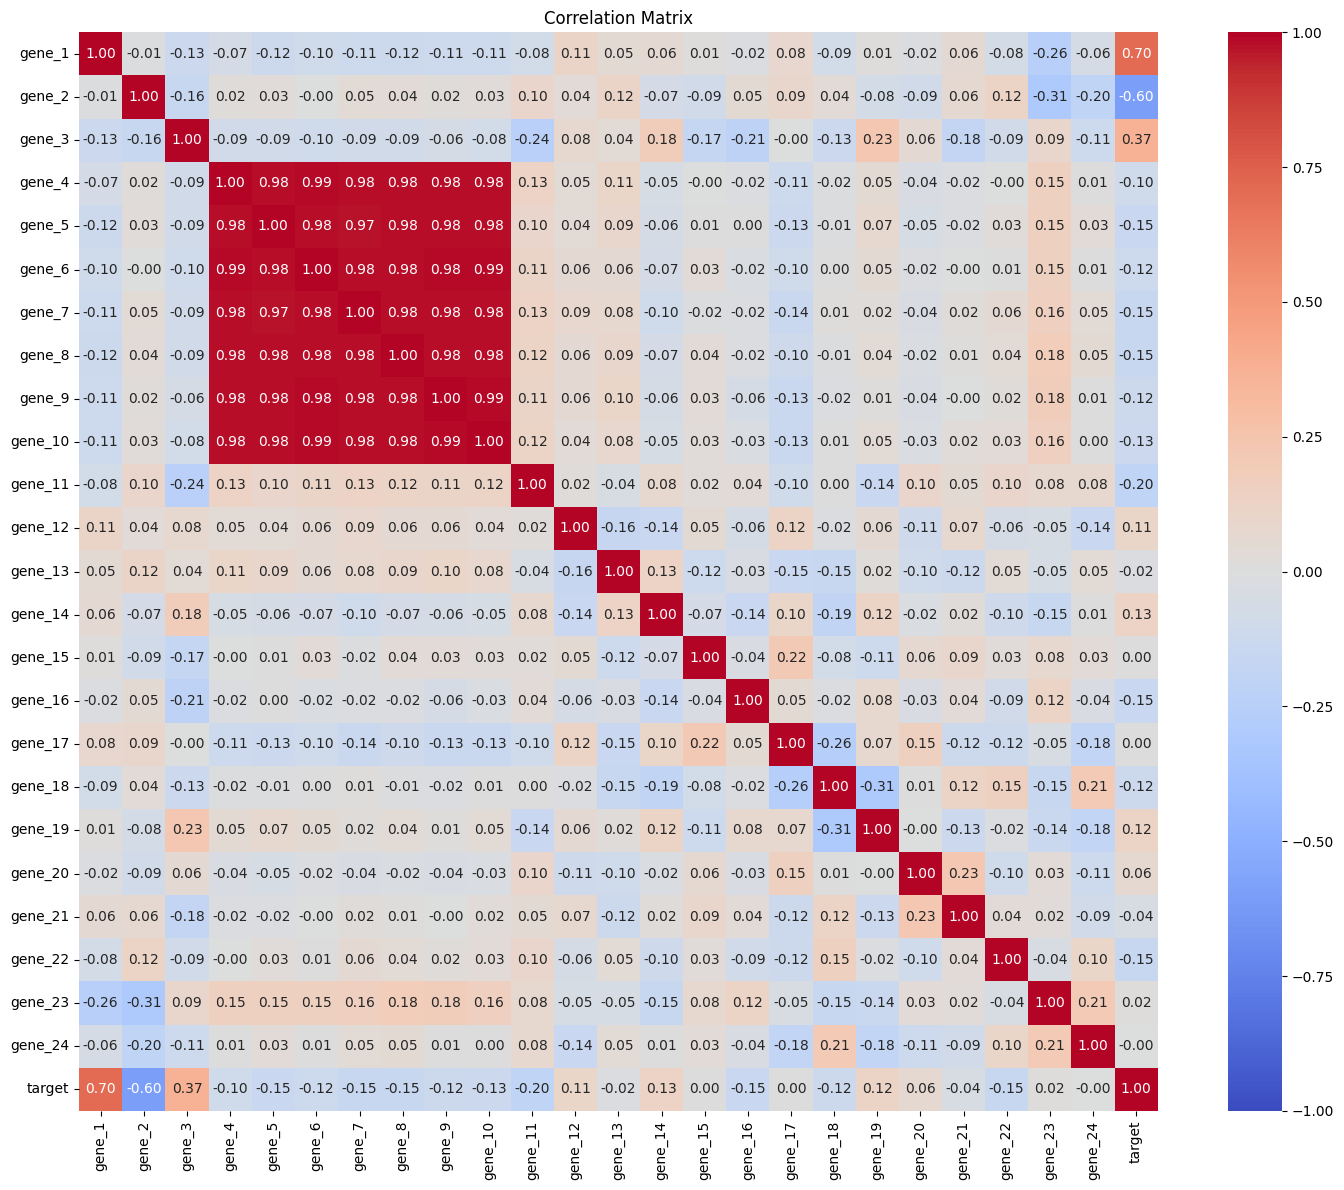

Ordinary Least Squares Regression Results:

   Train MSE  Test MSE  Train R2  Test R2   gene_1   gene_2  gene_3  gene_4  gene_5  gene_6  gene_7  gene_8  gene_9  gene_10  gene_11  gene_12  gene_13  gene_14  gene_15  gene_16  gene_17  gene_18  gene_19  gene_20  gene_21  gene_22  gene_23  gene_24
0      4.613   15.3154    0.9932   0.9609  19.7783 -14.5691  9.6433 -0.5818  -0.073  1.4127 -1.1405 -0.2664 -2.6495   3.0526  -0.3197   0.3803   0.1573  -0.1112  -0.1539  -0.5617  -0.5556  -0.0396  -0.7277   0.2915  -0.1557   0.2343   0.7527  -0.3035




Ridge Regression Results:

      Alpha  Train MSE  Test MSE  Train R2  Test R2   gene_1   gene_2  gene_3  gene_4  gene_5  gene_6  gene_7  gene_8  gene_9  gene_10  gene_11  gene_12  gene_13  gene_14  gene_15  gene_16  gene_17  gene_18  gene_19  gene_20  gene_21  gene_22  gene_23  gene_24
0     0.001     4.6130   15.3153    0.9932   0.9609  19.7778 -14.5687  9.6431 -0.5811 -0.0731  1.4122 -1.1402 -0.2670 -2.6470   3.0503  -0.3199   0.3803   0.1571 

/home/alain2op/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.187e+00, tolerance: 4.331e+00
  model = cd_fast.enet_coordinate_descent(


In [6]:
gene_data = pd.read_csv('gene_features.csv')
gene_x = gene_data.drop(columns=['target'])
gene_y = gene_data['target']
correlation_matrix(gene_data)
print("Ordinary Least Squares Regression Results:\n")
print(ols_results(gene_x, gene_y))
print("\n\n\n")
print("Ridge Regression Results:\n")
print(ridge_results(gene_x, gene_y))
print("\n\n\n")
print("Lasso Regression Results:\n")
print(lasso_results(gene_x, gene_y))

### Analysis

#### Q1

Only genes 1, 2, 3 correlate heavily with the target. Genes 4-10 are tightly correlated with each other but not with the target.

#### Q2

Best Ridge (α = 0.03): genes 4-10 still get non-zero coefficients. Ridge can't zero them out - it just shrinks everything proportionally.
Best Lasso (α = 0.1): genes 4-10 are all zeroed out. Lasso correctly identifies them as noise and drops them entirely.

#### Q4

Pushing λ higher forces the true gene coefficients (Eg. 1, 2, 3) down too. At this point , along with the noise the signal is being killed off. This is underfitting and hence model starts to perform worse.

#### Q6

Lasso gives a sparse vector with clear zeros; Ridge gives small but non-zero weights everywhere.

In [ ]:
gene_x_train, gene_x_test, gene_y_train, gene_y_test = train_test_split(gene_x, gene_y)

for alpha in [0.03, 0.1, 0.7]:
    m, tr_mse, te_mse, tr_r2, te_r2 = lasso_regression(gene_x_train, gene_y_train, gene_x_test, gene_y_test, alpha=alpha)
    selected = gene_x_train.columns[m.coef_ != 0].tolist()
    print(f'alpha={alpha:.2f}  selected={len(selected)} features  Test MSE={te_mse:.4f}  Test R2={te_r2:.4f}')
    print(f'  Features: {selected}')
    print()

# Best threshold: alpha=0.1 cleanly drops genes 4-10 while keeping driver genes
lasso_selector, _, _, _, _ = lasso_regression(gene_x_train, gene_y_train, gene_x_test, gene_y_test, alpha=0.1)
selected_features = gene_x_train.columns[lasso_selector.coef_ != 0].tolist()
print('Selected features for two-stage pipeline:', selected_features)

# --- Two-Stage Pipeline: lasso + ols
x_train_sel = gene_x_train[selected_features]
x_test_sel  = gene_x_test[selected_features]

ols_stage2 = LinearRegression()
ols_stage2.fit(x_train_sel, gene_y_train)
ols_preds = ols_stage2.predict(x_test_sel)

stage2_mse = mean_squared_error(gene_y_test, ols_preds)
stage2_r2  = r2_score(gene_y_test, ols_preds)

# Compare against pure Lasso (alpha=0.1)
_, _, lasso_mse, _, lasso_r2 = lasso_regression(gene_x_train, gene_y_train, gene_x_test, gene_y_test, alpha=0.1)

print(f'Pure Lasso (alpha=0.1):       Test MSE={lasso_mse:.4f}  Test R2={lasso_r2:.4f}')
print(f'Two-Stage (Lasso->OLS):       Test MSE={stage2_mse:.4f}  Test R2={stage2_r2:.4f}')
print()
print('Two-stage OLS coefficients:')
for feat, coef in zip(selected_features, ols_stage2.coef_):
    print(f'  {feat}: {coef:.4f}')

alpha=0.03  selected=21 features  Test MSE=14.8195  Test R2=0.9622
  Features: ['gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_7', 'gene_9', 'gene_10', 'gene_11', 'gene_12', 'gene_13', 'gene_14', 'gene_15', 'gene_16', 'gene_17', 'gene_18', 'gene_19', 'gene_20', 'gene_21', 'gene_22', 'gene_23', 'gene_24']

alpha=0.10  selected=13 features  Test MSE=14.7868  Test R2=0.9623
  Features: ['gene_1', 'gene_2', 'gene_3', 'gene_9', 'gene_11', 'gene_12', 'gene_14', 'gene_16', 'gene_17', 'gene_18', 'gene_19', 'gene_23', 'gene_24']

alpha=0.70  selected=3 features  Test MSE=16.4233  Test R2=0.9581
  Features: ['gene_1', 'gene_2', 'gene_3']

Selected features for two-stage pipeline: ['gene_1', 'gene_2', 'gene_3', 'gene_9', 'gene_11', 'gene_12', 'gene_14', 'gene_16', 'gene_17', 'gene_18', 'gene_19', 'gene_23', 'gene_24']
Pure Lasso (alpha=0.1):       Test MSE=14.7868  Test R2=0.9623
Two-Stage (Lasso->OLS):       Test MSE=14.3976  Test R2=0.9633

Two-stage OLS coefficients:
  gene_1: 19.8251
  gene_2:

### Q5 - Two-Stage Pipeline (Lasso Selection + OLS Refit)

Three Lasso thresholds were tried:
- alpha = 0.03: keeps too many features, some redundant noise genes survive
- alpha = 0.7: too aggressive, starts dropping real driver genes
- alpha = 0.1: cleanly zeros out genes 4-10 (the correlated noise block) while keeping the true driver genes

The two-stage approach:
1. Lasso (alpha=0.1) selects which features are non-zero
2. OLS is refit on only those selected features

This removes Lasso's shrinkage bias on the driver gene coefficients. The OLS refit recovers larger, unbiased coefficients for the true genes while the sparsity from step 1 filters out the noise. R2 improves slightly over pure Lasso because the coefficients are no longer pulled toward zero.

# Dataset 3 Sensor Features

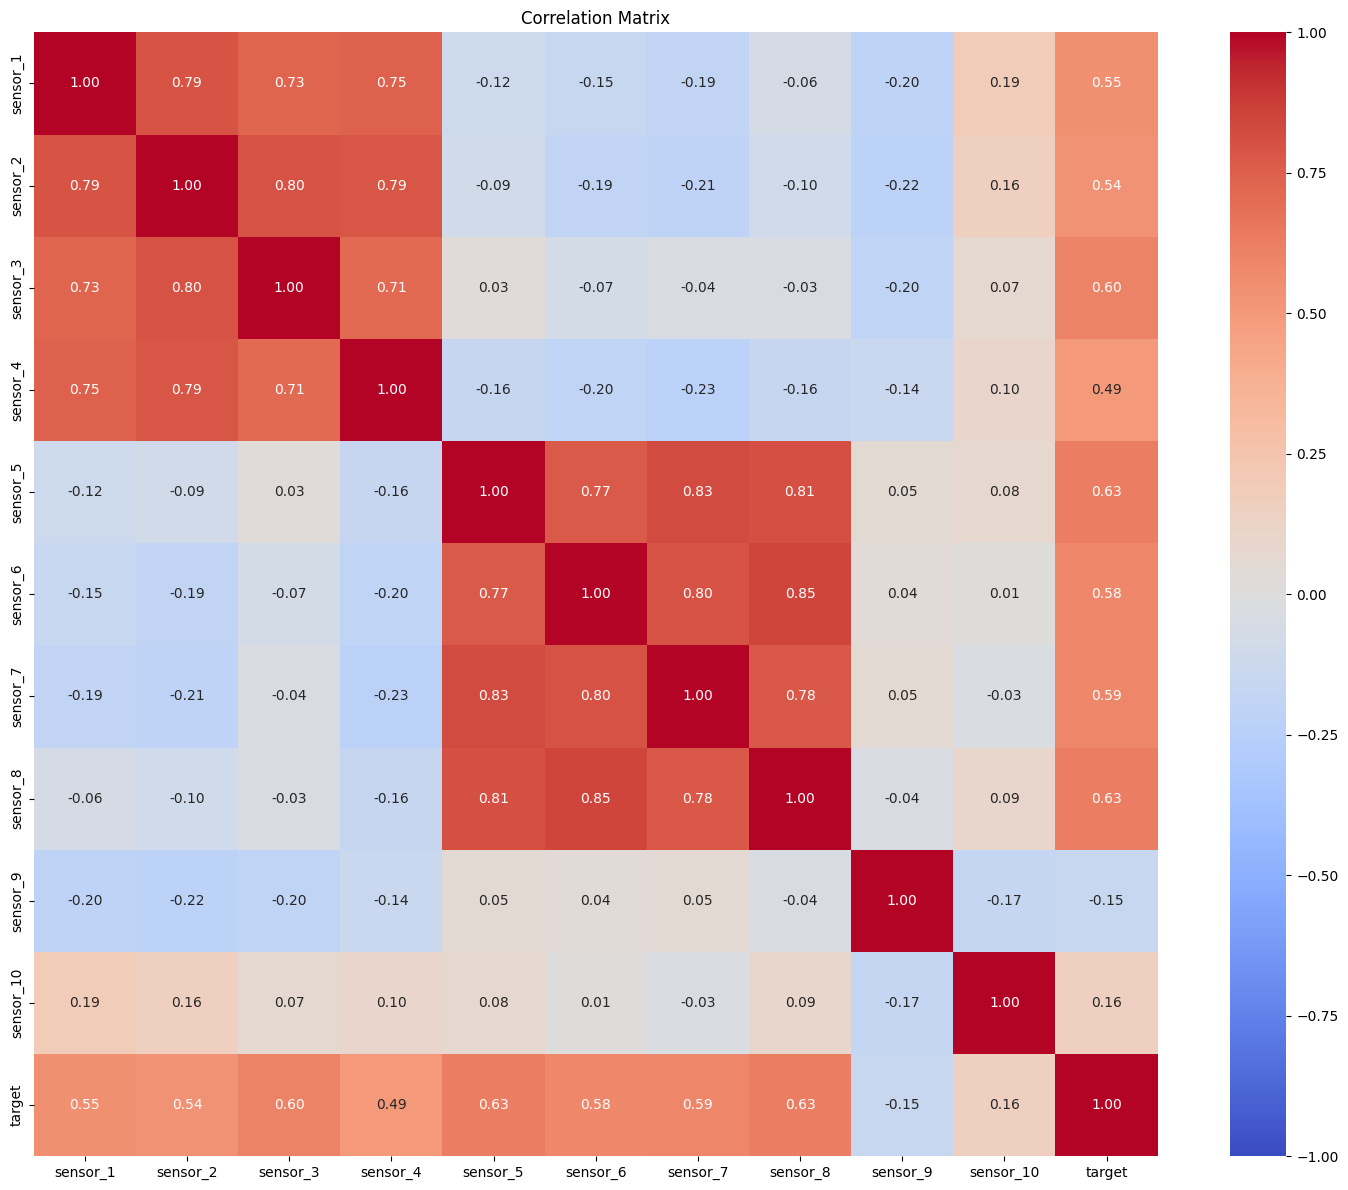

Ordinary Least Squares Regression Results:

   Train MSE  Test MSE  Train R2  Test R2  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  sensor_7  sensor_8  sensor_9  sensor_10
0     7.5702   17.9598    0.9549   0.7556    3.5656    1.4775    2.4797    2.0706    2.0579     2.399    3.2625    1.3106    -0.561     0.2092




Ridge Regression Results:

      Alpha  Train MSE  Test MSE  Train R2  Test R2  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  sensor_7  sensor_8  sensor_9  sensor_10
0     0.001     7.5702   17.9596    0.9549   0.7556    3.5655    1.4775    2.4797    2.0705    2.0579    2.3989    3.2624    1.3106   -0.5610     0.2092
1     0.003     7.5702   17.9592    0.9549   0.7556    3.5654    1.4776    2.4797    2.0705    2.0579    2.3989    3.2623    1.3107   -0.5609     0.2092
2     0.010     7.5702   17.9578    0.9549   0.7556    3.5650    1.4778    2.4797    2.0705    2.0580    2.3986    3.2619    1.3111   -0.5609     0.2092
3     0.030     7.5702   17

In [8]:
sensor_data = pd.read_csv('sensor_features.csv')
sensor_x = sensor_data.drop(columns=['target'])
sensor_y = sensor_data['target']
correlation_matrix(sensor_data)
print("Ordinary Least Squares Regression Results:\n")
print(ols_results(sensor_x, sensor_y))
print("\n\n\n")
print("Ridge Regression Results:\n")
print(ridge_results(sensor_x, sensor_y))
print("\n\n\n")
print("Lasso Regression Results:\n")
print(lasso_results(sensor_x, sensor_y))

### Analysis

#### Q1

Best model: **Ridge at α = 30**, Test MSE = 15.51 vs OLS baseline of 17.96 (~14% improvement). OLS overfits here because sensors 1-4 and 5-8 are highly correlated clusters, collinearity inflates coefficient variance which performs worse during testing. Ridge handles this directly.

#### Q2 - Cluster A (Sensors 1-4)

These four sensors measure the same thing, so ideally they'd have equal coefficients. In practice:
- **OLS:** coefficients are 3.57, 1.48, 2.48, 2.07 - std = **0.76**. Collinearity makes OLS split the shared effect arbitrarily.
- **Ridge (α = 30):** 2.77, 1.71, 2.30, 1.85 - std = **0.42**. Ridge pulls correlated coefficients toward each other. This is the grouping effect of ℓ2.
- **Lasso (α = 1):** coefficients spread even more wildly - std = **1.26**. Lasso picks one sensor and drops others rather than averaging, which is exactly the wrong behavior here.

#### Q3 - Noise Sensors (9 and 10)

Lasso (α = 1) zeros out both sensor_9 and sensor_10 correctly. Ridge (α = 30) keeps them at -0.45 and 0.24.

Yet Ridge still wins on Test MSE (15.51 vs ~18 for best Lasso), because here the benefit of properly averaging the 8 redundant cluster sensors outweighs the cost of retaining two small-weight noise sensors.
#### Q4 - Hybrid Pipeline

Lasso selects (zeroing out noise), Ridge estimates (averaging the cluster). The next cell implements this.

In [9]:
sensor_x_train, sensor_x_test, sensor_y_train, sensor_y_test = train_test_split(sensor_x, sensor_y)

lasso_selector = Lasso(alpha=1.0)
lasso_selector.fit(sensor_x_train, sensor_y_train)
selected_sensors = sensor_x.columns[lasso_selector.coef_ != 0].tolist()
noise_sensors = sensor_x.columns[lasso_selector.coef_ == 0].tolist()

print("Lasso (alpha=1) selected sensors:", selected_sensors)
print("Lasso (alpha=1) zeroed sensors (noise):", noise_sensors)

x_train_sel = sensor_x_train[selected_sensors]
x_test_sel = sensor_x_test[selected_sensors]

ridge_hybrid = Ridge(alpha=30)
ridge_hybrid.fit(x_train_sel, sensor_y_train)

hybrid_pred = ridge_hybrid.predict(x_test_sel)
hybrid_test_mse = mean_squared_error(sensor_y_test, hybrid_pred)
hybrid_test_r2 = r2_score(sensor_y_test, hybrid_pred)

print(f"\nHybrid Pipeline Test MSE: {hybrid_test_mse:.4f}")
print(f"Hybrid Pipeline Test R²:  {hybrid_test_r2:.4f}")
print(f"\nBaseline Ridge(30) Test MSE: 15.5067")
print(f"Improvement: {15.5067 - hybrid_test_mse:.4f} MSE units")

Lasso (alpha=1) selected sensors: ['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8']
Lasso (alpha=1) zeroed sensors (noise): ['sensor_9', 'sensor_10']

Hybrid Pipeline Test MSE: 15.0274
Hybrid Pipeline Test R²:  0.7955

Baseline Ridge(30) Test MSE: 15.5067
Improvement: 0.4793 MSE units
